# Full FWI **inversion** via batched per-shot local windows — Marmousi

<p align="center">
  <img src="../../figures/batched_local_window_schematic.svg" alt="Batched per-shot local-window FWI" width="920">
</p>


A complete frequency-continuation FWI that recovers Marmousi from a smooth start. Every iteration
computes the misfit gradient by forwarding **all shots' local model windows in one batched solver
call** — shot `b` propagates in its own `(B, nz, W)` crop. Because a towed streamer is
translation-invariant (fixed cable), every window has the **same shape**, so the crops stack into a
single batched tensor. Overlapping windows scatter-add onto the full model automatically through
autograd. Runs on a single GPU with `impl='c'` + boundary saving.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh = MARMOUSI_DH          # 12.5 m
dt = 0.0012               # CFL: 4700 * 0.0012 / 12.5 = 0.45 < 0.555 (8th-order 2-D)
nt = 3000                 # 3.6 s — long enough for the deep far-offset reflections (~2.9 s)

nrec, rec_dx = 160, 2     # 160 receivers every 2 cells -> ~4 km streamer cable
srcdx, nshot = 50, 20     # source every 50 cells (625 m), 20 shots
src_z, rec_z = 4, 3
pad_x        = 25         # local-window padding around each shot's aperture (cells)

# One broadband Ricker source; the observed data is modelled once, up front.
# Frequency continuation is then done by low-pass filtering syn & obs to each
# band's cutoff inside the loss — not by re-modelling with a new source.
src_freq, src_delay = 10.0, 0.15
bands = [
    {'f_max':  4.0, 'n_iter': 35, 'lr': 20.0},
    {'f_max':  8.0, 'n_iter': 35, 'lr': 14.0},
    {'f_max': 12.0, 'n_iter': 45, 'lr': 10.0},
]
grad_sigma = 2.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 1 — Marmousi, streamer geometry, and per-shot local windows

The known ~450 m water layer is reset to 1500 m/s and frozen (marine convention). Each shot's
window spans its source + trailing cable plus padding; the fixed cable makes every window the same
width `W`, so they batch.

In [2]:
vp_true = load_marmousi('true').astype(np.float32)
vp_init = load_marmousi('smooth').astype(np.float32)
nz, nx  = vp_true.shape

# Fix the known water layer to 1500 m/s — the smooth start had blurred it.
n_water = int(np.argmax(vp_true.max(1) > 1501))     # first row below the 1500 water column
vp_init = vp_init.copy()
vp_init[:n_water] = 1500.0
print(f'water layer: rows 0:{n_water} ({n_water * dh:.0f} m) fixed to 1500 m/s')

# Streamer: source steps to the right, a fixed cable trails to the left.
src_x     = (nrec - 1) * rec_dx + 30 + srcdx * np.arange(nshot)
sources   = np.stack([src_x, np.full(nshot, src_z)], axis=1).astype(np.int64)
receivers = np.zeros((nshot, nrec, 2), dtype=np.int64)
for s in range(nshot):
    receivers[s, :, 0] = src_x[s] - (nrec - 1 - np.arange(nrec)) * rec_dx
    receivers[s, :, 1] = rec_z

# Per-shot local windows: [aperture - pad, aperture + pad], all the same width W.
lo = np.minimum(src_x, receivers[..., 0].min(1)) - pad_x
hi = np.maximum(src_x, receivers[..., 0].max(1)) + pad_x
W  = int((hi - lo).max())
x0 = np.clip(lo, 0, nx - W).astype(int)

# Geometry rebased into window-local coordinates.
loc_sources         = sources.copy()
loc_sources[:, 0]  -= x0
loc_receivers       = receivers.copy()
for s in range(nshot):
    loc_receivers[s, :, 0] -= x0[s]

print(f'{nshot} shots, window W = {W} cells ({W * dh / 1000:.2f} km) — all the same shape')

water layer: rows 0:37 (462 m) fixed to 1500 m/s
20 shots, window W = 368 cells (4.60 km) — all the same shape


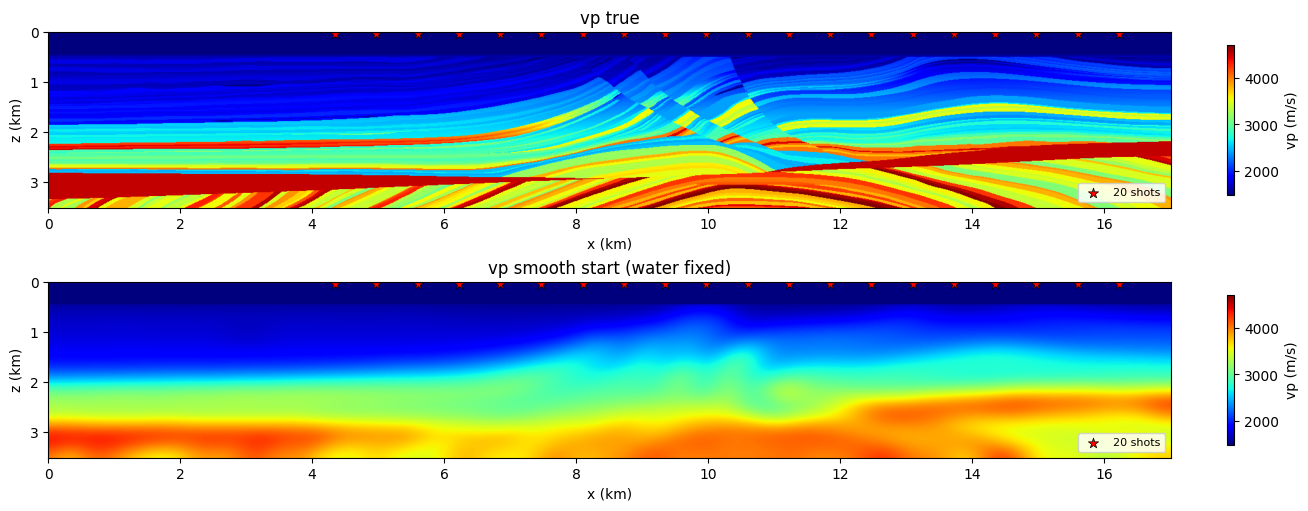

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5), constrained_layout=True)
for ax, m, title in zip(axes, [vp_true, vp_init], ['true', 'smooth start (water fixed)']):
    im = ax.imshow(m, cmap='jet', aspect='auto', vmin=1500, vmax=4700,
                   extent=[0, nx * dh / 1000, nz * dh / 1000, 0])
    ax.scatter(src_x * dh / 1000, np.full(nshot, src_z * dh / 1000),
               s=60, c='red', marker='*', edgecolors='k', linewidths=0.5, label=f'{nshot} shots')
    ax.set_title(f'vp {title}')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('z (km)')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.85)
    fig.colorbar(im, ax=ax, label='vp (m/s)', shrink=0.85)
plt.show()

## 2 — Solver (impl='c' + boundary saving) and the batched local-window forward

In [4]:
boundary_saving = {'memory': {'strategy': 'boundary', 'boundary': {'storage': 'gpu'}}}

equation = Acoustic(device=device, spatial_order=8)
solver   = PropTorch(equation, shape=(nz, W), dh=dh, dt=dt, nt=nt,
                     abcn=25, free_surface=True, impl='c',
                     cuda_options=boundary_saving)
print('impl:', solver.impl)


def batched_syn(vp_full, wavelet):
    """Forward every shot at once, each in its own local model window (B, nz, W)."""
    crops = torch.stack([vp_full[:, x0[s]:x0[s] + W] for s in range(nshot)])
    return solver(wavelet, loc_sources, loc_receivers, models=[crops])


def lowpass(x, f_max, taper_hz=0.5):
    """Differentiable zero-phase low-pass along the time axis (dim 1)."""
    freqs   = torch.fft.rfftfreq(x.shape[1], d=dt, device=x.device)
    fade_lo = max(f_max - taper_hz, 0.5 * f_max)
    ramp    = 0.5 * (1 + torch.cos(np.pi * (freqs - fade_lo) / (f_max - fade_lo)))
    mask    = torch.where(freqs <= fade_lo, torch.ones_like(freqs),
                          torch.where(freqs >= f_max, torch.zeros_like(freqs), ramp))
    spec = torch.fft.rfft(x, dim=1) * mask.view(1, -1, 1, 1)
    return torch.fft.irfft(spec, n=x.shape[1], dim=1)


# Model the observed data ONCE with the broadband source.
t         = np.arange(nt, dtype=np.float32) * dt
wavelet   = ricker(t - src_delay, f=src_freq).astype(np.float32)
vp_true_t = torch.tensor(vp_true, device=device)
with torch.no_grad():
    obs = batched_syn(vp_true_t, wavelet).detach()
print('observed data modelled once:', tuple(obs.shape))

impl: c
observed data modelled once: (20, 3000, 160, 1)


## 3 — Frequency-continuation FWI loop

The observed data is modelled **once** with the broadband source. Each band then low-passes **syn and obs** to its cutoff (4 → 8 → 12 Hz) inside the loss and Adam-descends the full model. The gradient is Gaussian-smoothed, the water layer is frozen, and overlapping windows scatter-add back onto `vp` through autograd.

In [5]:
# Freeze the fixed water layer; ramp the gradient in just below the seabed.
water_mask = np.ones(nz, dtype=np.float32)
water_mask[:n_water]            = 0.0
water_mask[n_water:n_water + 6] = np.linspace(0, 1, 6) ** 2

vp                 = torch.tensor(vp_init, device=device, requires_grad=True)
losses, band_edges = [], []

for band in bands:
    f_max, n_iter = band['f_max'], band['n_iter']
    opt    = torch.optim.Adam([vp], lr=band['lr'])
    obs_lp = lowpass(obs, f_max)                       # filter the observed data once per band
    for _ in range(n_iter):
        opt.zero_grad()
        syn_lp = lowpass(batched_syn(vp, wavelet), f_max)
        loss   = 0.5 * ((syn_lp - obs_lp) ** 2).sum()
        loss.backward()

        grad    = gaussian_filter(vp.grad.detach().cpu().numpy(), grad_sigma)
        vp.grad = torch.tensor(grad * water_mask[:, None], device=device)
        opt.step()
        with torch.no_grad():
            vp.clamp_(1500.0, 5000.0)
        losses.append(float(loss))

    band_edges.append(len(losses))
    print(f'  ≤ {f_max:.0f} Hz: {n_iter} iters, loss -> {losses[-1]:.3e}')

vp_inv = vp.detach().cpu().numpy()

/tmp/ipykernel_3567710/1422210664.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(loss))


  ≤ 4 Hz: 35 iters, loss -> 7.957e+00


  ≤ 8 Hz: 35 iters, loss -> 8.131e+02


  ≤ 12 Hz: 45 iters, loss -> 1.004e+03


## 4 — Result: recovered model and misfit

model RMSE below seabed : 336.9 -> 238.4 m/s
perturbation correlation: 0.709


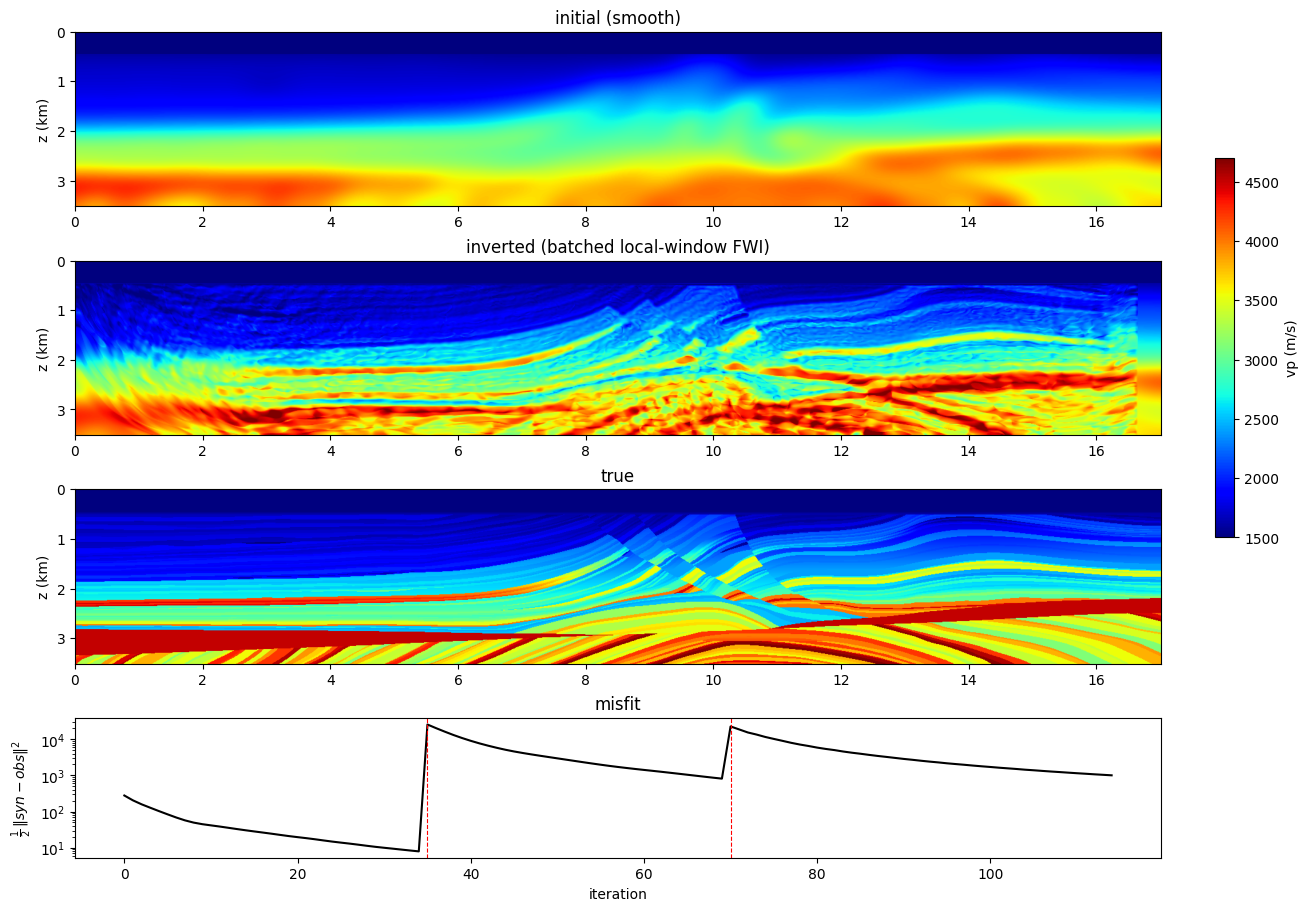

In [6]:
# Score below the fixed water layer, within the streamer's shallow-resolvable depth.
illum = np.zeros(nx, dtype=bool)
for s in range(nshot):
    illum[x0[s]:x0[s] + W] = True

z_max = 200
mask  = np.zeros((nz, nx), dtype=bool)
mask[n_water:z_max, illum] = True

def rmse(v):
    return float(np.sqrt(((v - vp_true)[mask] ** 2).mean()))

dp_inv  = (vp_inv  - vp_init)[mask]
dp_true = (vp_true - vp_init)[mask]
pcc     = float(dp_inv @ dp_true / (np.linalg.norm(dp_inv) * np.linalg.norm(dp_true)))
print(f'model RMSE below seabed : {rmse(vp_init):.1f} -> {rmse(vp_inv):.1f} m/s')
print(f'perturbation correlation: {pcc:.3f}')

fig, axes = plt.subplots(4, 1, figsize=(13, 9),
                         gridspec_kw={'height_ratios': [1, 1, 1, 0.8]},
                         constrained_layout=True)
for ax, m, title in zip(axes[:3], [vp_init, vp_inv, vp_true],
                        ['initial (smooth)', 'inverted (batched local-window FWI)', 'true']):
    im = ax.imshow(m, cmap='jet', aspect='auto', vmin=1500, vmax=4700,
                   extent=[0, nx * dh / 1000, nz * dh / 1000, 0])
    ax.set_title(title)
    ax.set_ylabel('z (km)')
fig.colorbar(im, ax=axes[:3], label='vp (m/s)', shrink=0.6)

axes[3].semilogy(losses, 'k')
for e in band_edges[:-1]:
    axes[3].axvline(e, color='r', ls='--', lw=0.8)
axes[3].set_title('misfit')
axes[3].set_xlabel('iteration')
axes[3].set_ylabel(r'$\frac{1}{2}\,\|syn-obs\|^2$')
plt.show()